In [1]:
#loading filtered rna data
import anndata
from anndata import AnnData

pb_rna_ct = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes/agg_rna_ct.h5ad")
pb_rna_ct_t = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes_times/agg_rna_ct_time.h5ad")


In [7]:
len(pb_rna_ct.var_names)

32057

In [19]:
pb_rna_ct_t.X[1:5,1:5]

array([[7.66836970e-07, 3.02134707e-06, 0.00000000e+00, 3.67114262e-06],
       [2.09986640e-06, 7.08646177e-06, 6.79622346e-07, 1.60289652e-06],
       [2.70624734e-06, 6.22333680e-06, 2.82465431e-07, 3.25717672e-06],
       [2.75671970e-06, 7.20522830e-06, 0.00000000e+00, 4.74530488e-06]])

# UMAP
- Each point is one cell type pseudobulk profile
- Cell types that sit near each other have similar averaged expression patterns

/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


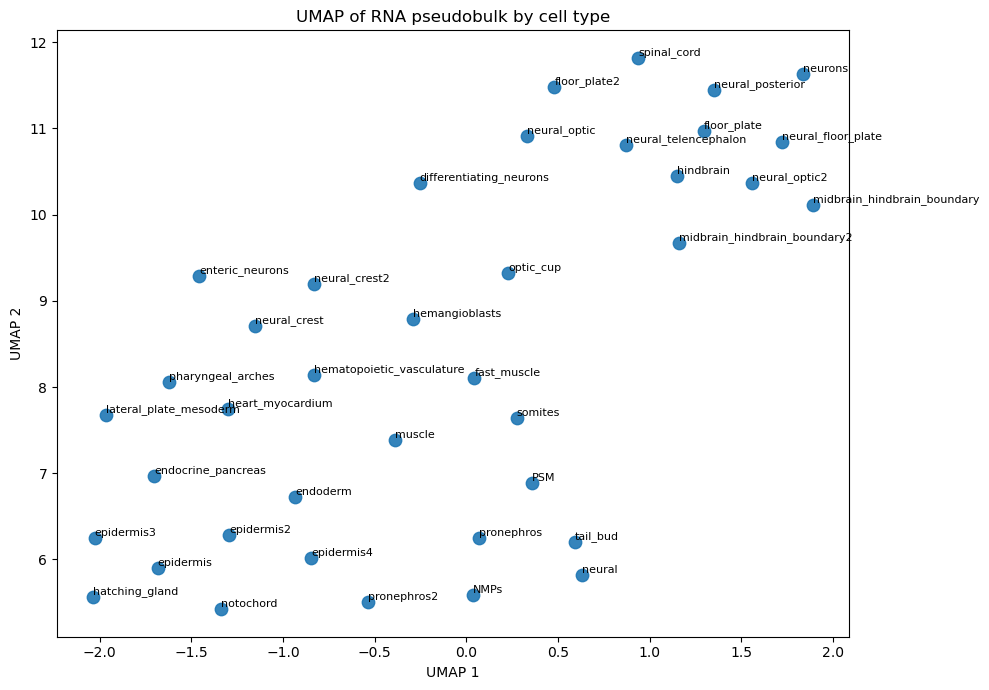

In [8]:
# Applying UMAP to pseudobulk matrix (rows = cell types, columns = genes)
import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Extract expression matrix
X = pb_rna_ct.X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.asarray(X, dtype=float)

# Optional transform for count-like data
#X = np.log1p(X)

# Scale features (genes) before UMAP
X_scaled = StandardScaler().fit_transform(X)

# UMAP
n_neighbors = min(15, X_scaled.shape[0] - 1) if X_scaled.shape[0] > 1 else 1
reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.3, metric="cosine", random_state=42)
embedding = reducer.fit_transform(X_scaled)

# Labels are cell-type names from row index
labels = pb_rna_ct.obs_names.astype(str)

# Plot and annotate each cell type
plt.figure(figsize=(10, 7))
plt.scatter(embedding[:, 0], embedding[:, 1], s=80, alpha=0.9)
for i, label in enumerate(labels):
    plt.text(embedding[i, 0], embedding[i, 1], label, fontsize=8, ha="left", va="bottom")

plt.title("UMAP of RNA pseudobulk by cell type")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

# Correlation Heatmap
- This shows which cell types have similar expression profiles
- High positive values mean two cell types look similar across genes
- It is useful for quality control and for spotting biological relationships

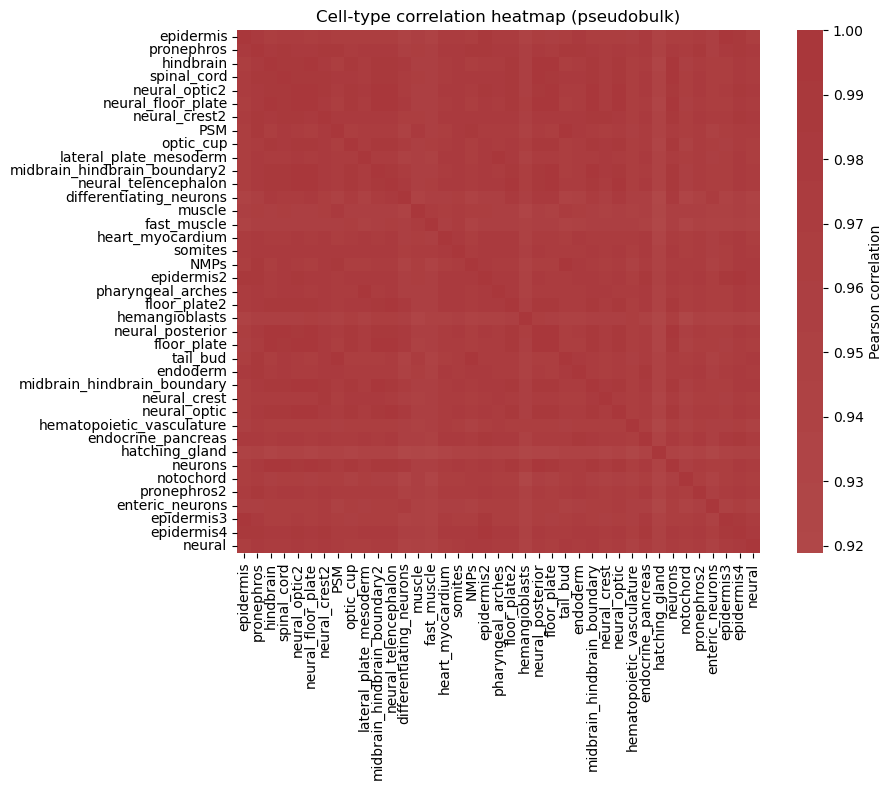

In [3]:
# 1) Sample-to-sample similarity heatmap (cell type correlation)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X = pb_rna_ct.X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.asarray(X, dtype=float)
labels = pb_rna_ct.obs_names.astype(str)

# Optional stabilization for count-like values
#X_log = np.log1p(X)

corr = np.corrcoef(X)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    xticklabels=labels,
    yticklabels=labels,
    cmap="vlag",
    center=0,
    square=True,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Cell-type correlation heatmap (pseudobulk)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# PCA Plot
- PCA gives a linear view of the largest sources of variation
- It is often easier to interpret than UMAP for small sample counts
- The variance percentages help you judge how informative the plot is

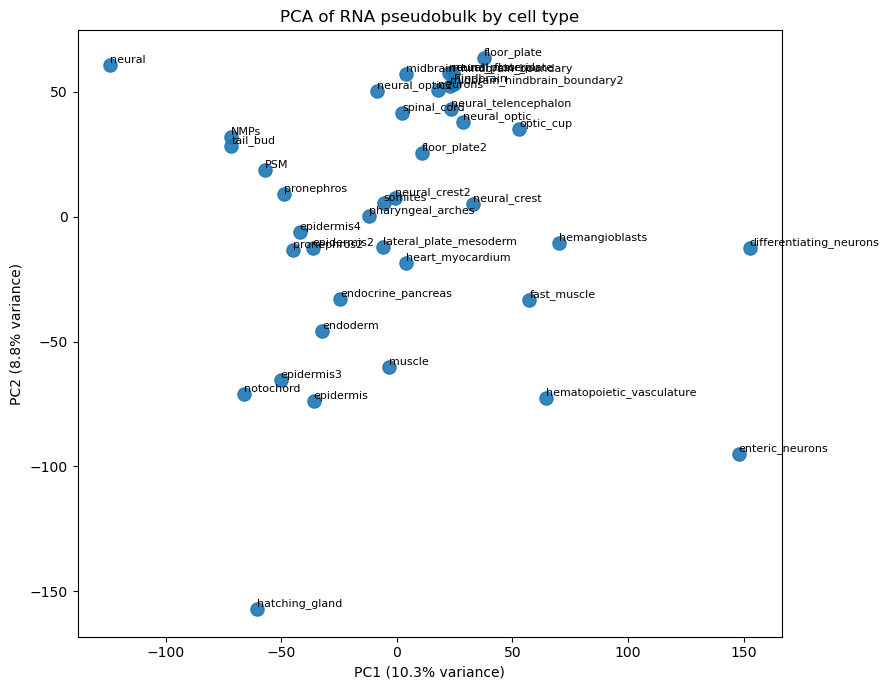

In [6]:
# 2) PCA plot with cell-type labels
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = pb_rna_ct.X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.asarray(X, dtype=float)
labels = pb_rna_ct.obs_names.astype(str)

#X_log = np.log1p(X)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
plt.scatter(pcs[:, 0], pcs[:, 1], s=90, alpha=0.9)
for i, label in enumerate(labels):
    plt.text(pcs[i, 0], pcs[i, 1], label, fontsize=8, ha="left", va="bottom")

var_exp = pca.explained_variance_ratio_ * 100
plt.xlabel(f"PC1 ({var_exp[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({var_exp[1]:.1f}% variance)")
plt.title("PCA of RNA pseudobulk by cell type")
plt.tight_layout()
plt.show()

# Clustered heatmap of top variable genes
- usually the most biologically informative plot in a pseudobulk dataset
- It shows which genes vary most across cell types
- The clustering can reveal groups of similar cell types and shared gene programs

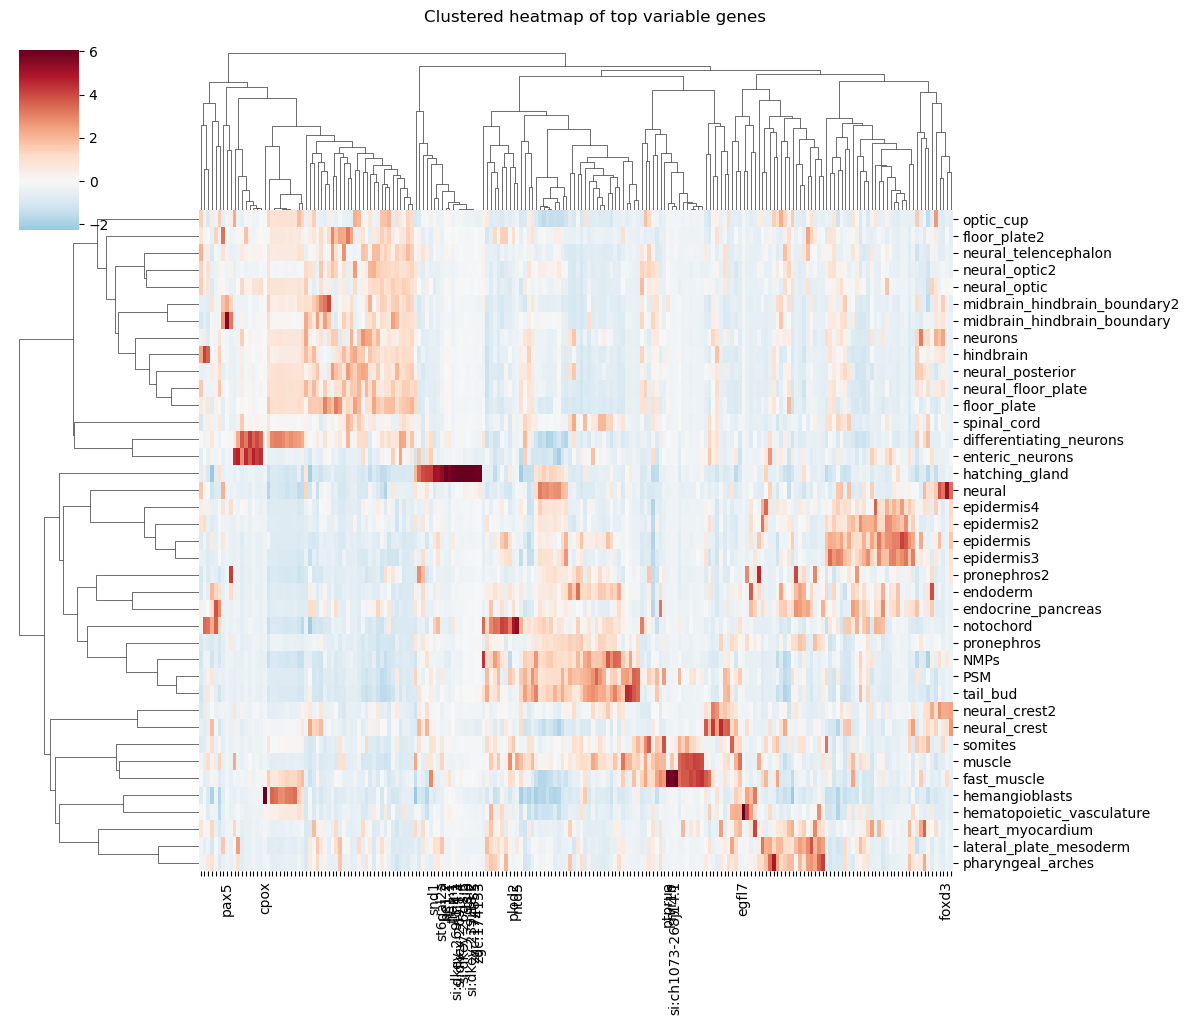

In [13]:
# 3) Top-variable-gene clustered heatmap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

X = pb_rna_ct.X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.asarray(X, dtype=float)

# Use log transform for stability
X_log = np.log1p(X)

# Select top variable genes across cell types
n_top_genes = min(200, X_log.shape[1])
gene_var = X_log.var(axis=0)
top_idx = np.argsort(gene_var)[-n_top_genes:]

heat_df = pd.DataFrame(
    X_log[:, top_idx],
    index=pb_rna_ct.obs_names.astype(str),
    columns=np.array(pb_rna_ct.var_names)[top_idx],
)

# Z-score by gene for visualization
heat_df_z = (heat_df - heat_df.mean(axis=0)) / (heat_df.std(axis=0) + 1e-8)

# Show only x-axis labels for genes with at least one z-score value > 5
xtick_labels = np.where(heat_df_z.max(axis=0).to_numpy() > 5, heat_df.columns, "")

sns.clustermap(
    heat_df_z,
    cmap="RdBu_r",
    center=0,
    figsize=(12, 10),
    xticklabels=xtick_labels,
    yticklabels=True,
    metric="correlation",
    method="average",
)
plt.suptitle("Clustered heatmap of top variable genes", y=1.02)
plt.show()